# Analysis for Reproducibility of Generative Models

## 1. t-SNE based analysis
Uses `extrct_training_feats.npz`, `extrct_edm_feats.npz`, `extrct_dmd_feats.npz` in a class folder.
Background = training (very light); left = EDM (alpha by t-SNE x); right = DMD (same alpha as matching EDM).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Class folder containing the four npz files (e.g. 207_Golden_Retriever)
CLASS_DIR = "tsne_edm_vs_dmd/248_husky"
CLASS_INDEX = 248

## 1.1 EDM_N, EDM_1, DMD, and training set: ResNet + t-SNE

In [2]:
train = np.load(f"{CLASS_DIR}/extrct_training_feats.npz")
edm_N = np.load(f"{CLASS_DIR}/extrct_edm_N_feats.npz")
edm_1 = np.load(f"{CLASS_DIR}/extrct_edm_1_feats.npz")
dmd = np.load(f"{CLASS_DIR}/extrct_dmd_feats.npz")

bg_feats = train["features"]
edm_N_feats = edm_N["features"]
edm_1_feats = edm_1["features"]
dmd_feats = dmd["features"]

n_bg, n_edm_N, n_edm_1, n_dmd = len(bg_feats), len(edm_N_feats), len(edm_1_feats), len(dmd_feats)
print(f"Training: {n_bg}, EDM_N: {n_edm_N}, EDM_1: {n_edm_1}, DMD: {n_dmd}")

Training: 1300, EDM_N: 500, EDM_1: 500, DMD: 500


In [3]:
all_feats = np.concatenate([bg_feats, edm_N_feats, edm_1_feats, dmd_feats], axis=0)
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, init="pca", random_state=0, verbose=1)
all_2d = tsne.fit_transform(all_feats)

bg_2d = all_2d[:n_bg]
edm_N_2d = all_2d[n_bg : n_bg + n_edm_N]
edm_1_2d = all_2d[n_bg + n_edm_N : n_bg + n_edm_N + n_edm_1]
dmd_2d = all_2d[n_bg + n_edm_N + n_edm_1 :]

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2800 samples in 0.003s...
[t-SNE] Computed neighbors for 2800 samples in 0.507s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2800
[t-SNE] Computed conditional probabilities for sample 2000 / 2800
[t-SNE] Computed conditional probabilities for sample 2800 / 2800
[t-SNE] Mean sigma: 1.916282
[t-SNE] KL divergence after 250 iterations with early exaggeration: 77.095566
[t-SNE] KL divergence after 1000 iterations: 2.016782


/tmp/ipykernel_3954680/2243698215.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("coolwarm")  # blue(0) to red(1)


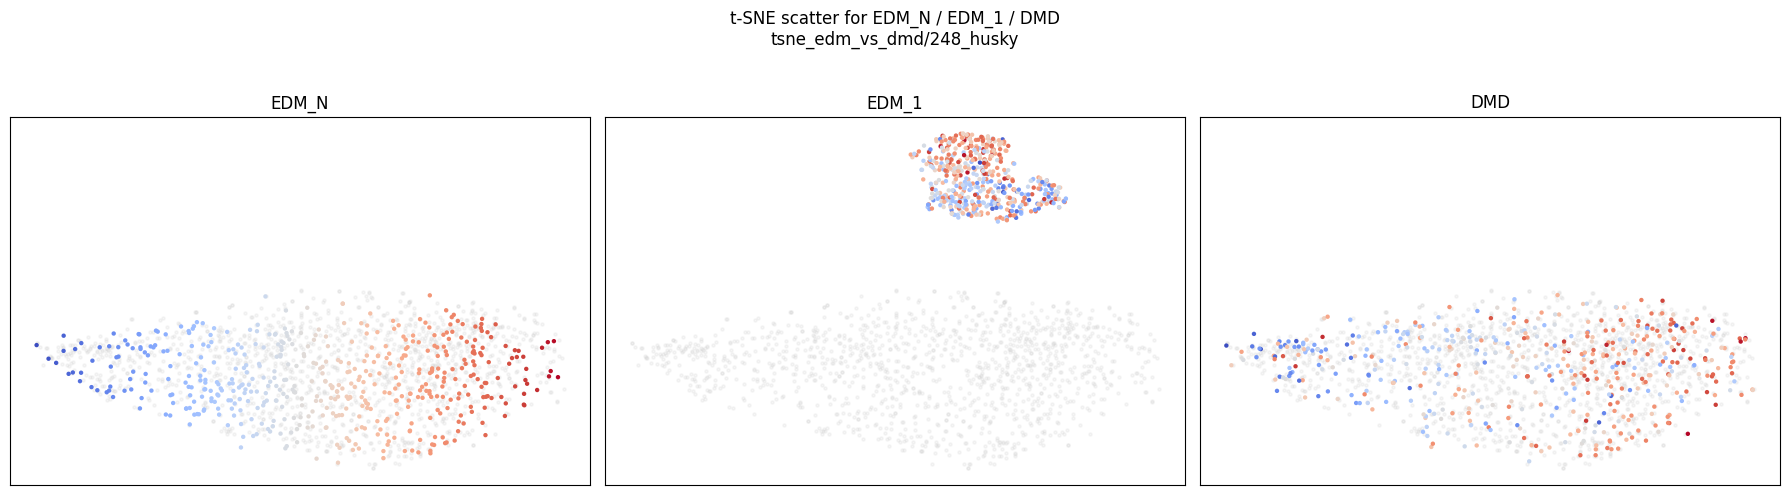

Saved tsne_edm_vs_dmd/248_husky/tSNE_EDMN_EDM1_DMD.png


In [4]:
min_pairs = min(n_edm_N, n_edm_1, n_dmd)
# 取对应于EDM_N、EDM_1、DMD的min_pairs个点在t-SNE空间
edm_N_2d = edm_N_2d[:min_pairs]
edm_1_2d = edm_1_2d[:min_pairs]
dmd_2d = dmd_2d[:min_pairs]

# 以EDM_N点x轴排序作为着色依托
edm_N_x = edm_N_2d[:, 0]
x_min, x_max = edm_N_x.min(), edm_N_x.max()
x_norm = (edm_N_x - x_min) / (x_max - x_min + 1e-12)
cmap = plt.cm.get_cmap("coolwarm")  # blue(0) to red(1)
colors = cmap(x_norm)  # (N, 4) RGBA

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax in axes:
    ax.scatter(bg_2d[:, 0], bg_2d[:, 1], s=5, c="lightgray", alpha=0.2, label="Train")
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].scatter(edm_N_2d[:, 0], edm_N_2d[:, 1], s=10, color=colors, edgecolors="none")
axes[0].set_title("EDM_N")
axes[0].set_xticks([]); axes[0].set_yticks([])

axes[1].scatter(edm_1_2d[:, 0], edm_1_2d[:, 1], s=10, color=colors, edgecolors="none")
axes[1].set_title("EDM_1")
axes[1].set_xticks([]); axes[1].set_yticks([])

axes[2].scatter(dmd_2d[:, 0], dmd_2d[:, 1], s=10, color=colors, edgecolors="none")
axes[2].set_title("DMD")
axes[2].set_xticks([]); axes[2].set_yticks([])

fig.suptitle(f"t-SNE scatter for EDM_N / EDM_1 / DMD\n{CLASS_DIR}")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{CLASS_DIR}/tSNE_EDMN_EDM1_DMD.png", dpi=200)
plt.show()
print(f"Saved {CLASS_DIR}/tSNE_EDMN_EDM1_DMD.png")




## 1.2 EDM_N - DMD: t-SNE

Plot $K$ pairs of images with largest / smallest t-SNE distance (between EDM_N and DMD)

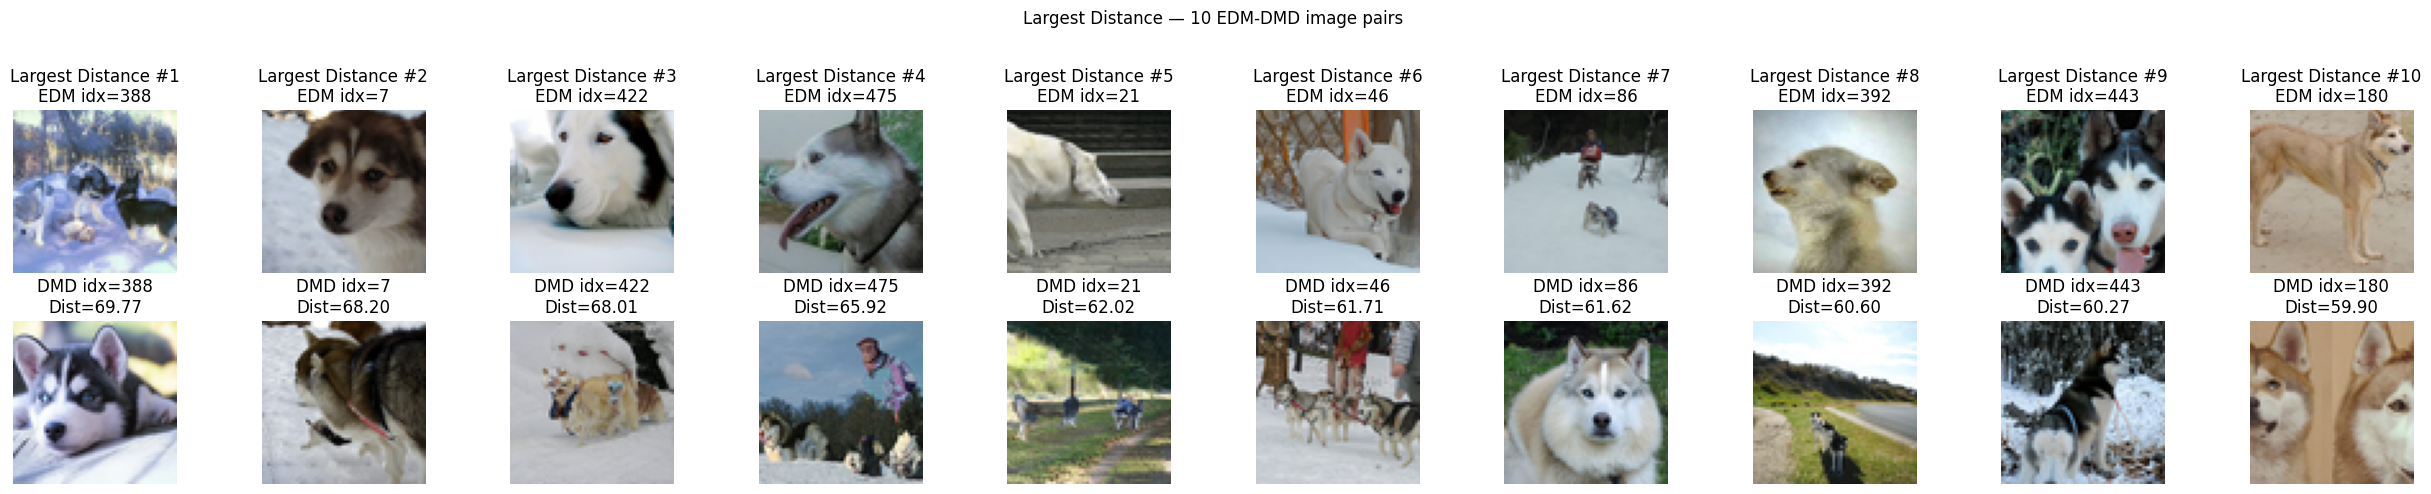

Saved tsne_edm_vs_dmd/248_husky/img_EDM_DMD_largest_10_pairs.png


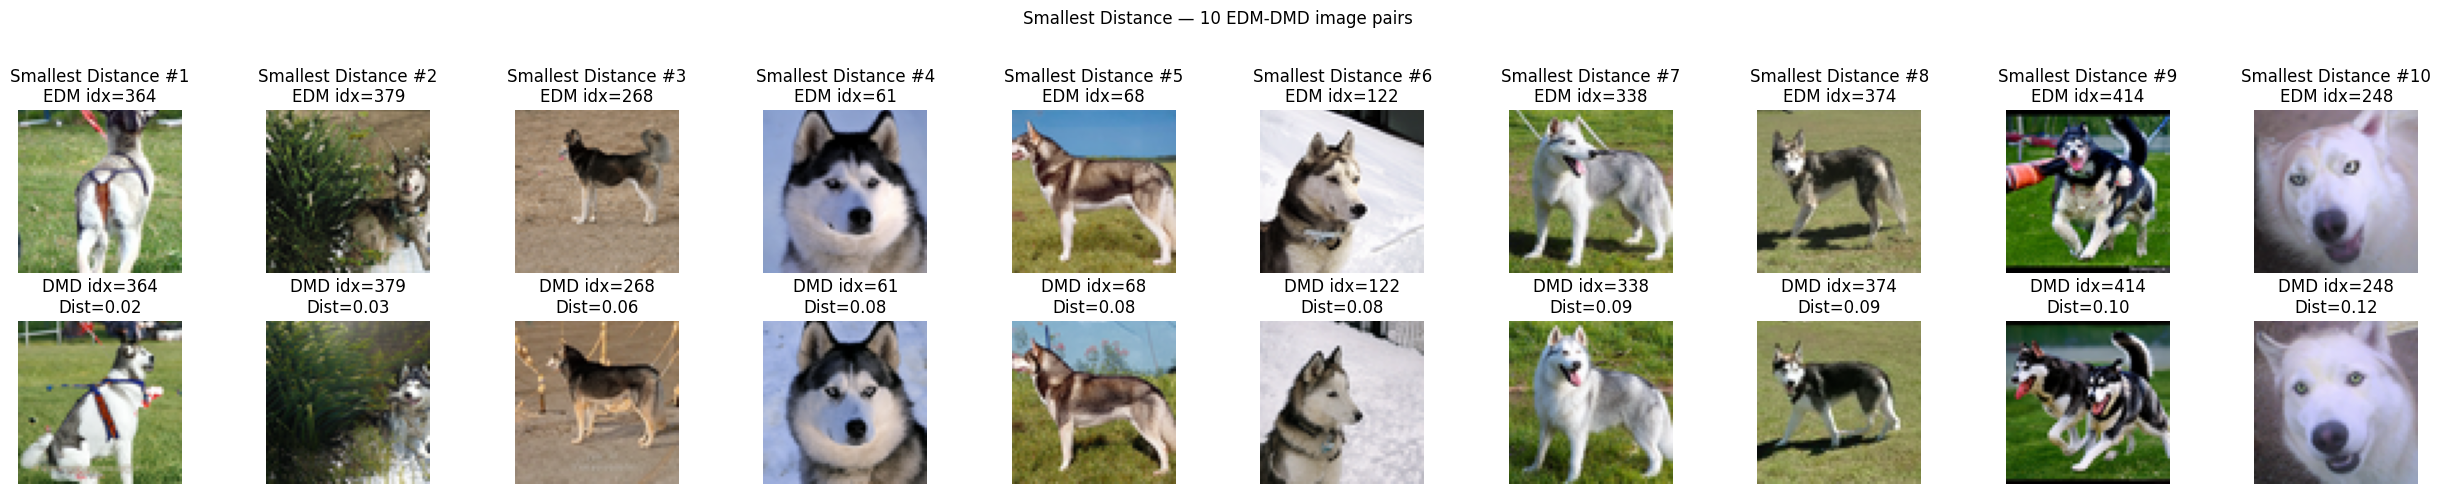

Saved tsne_edm_vs_dmd/248_husky/img_EDM_DMD_smallest_10_pairs.png


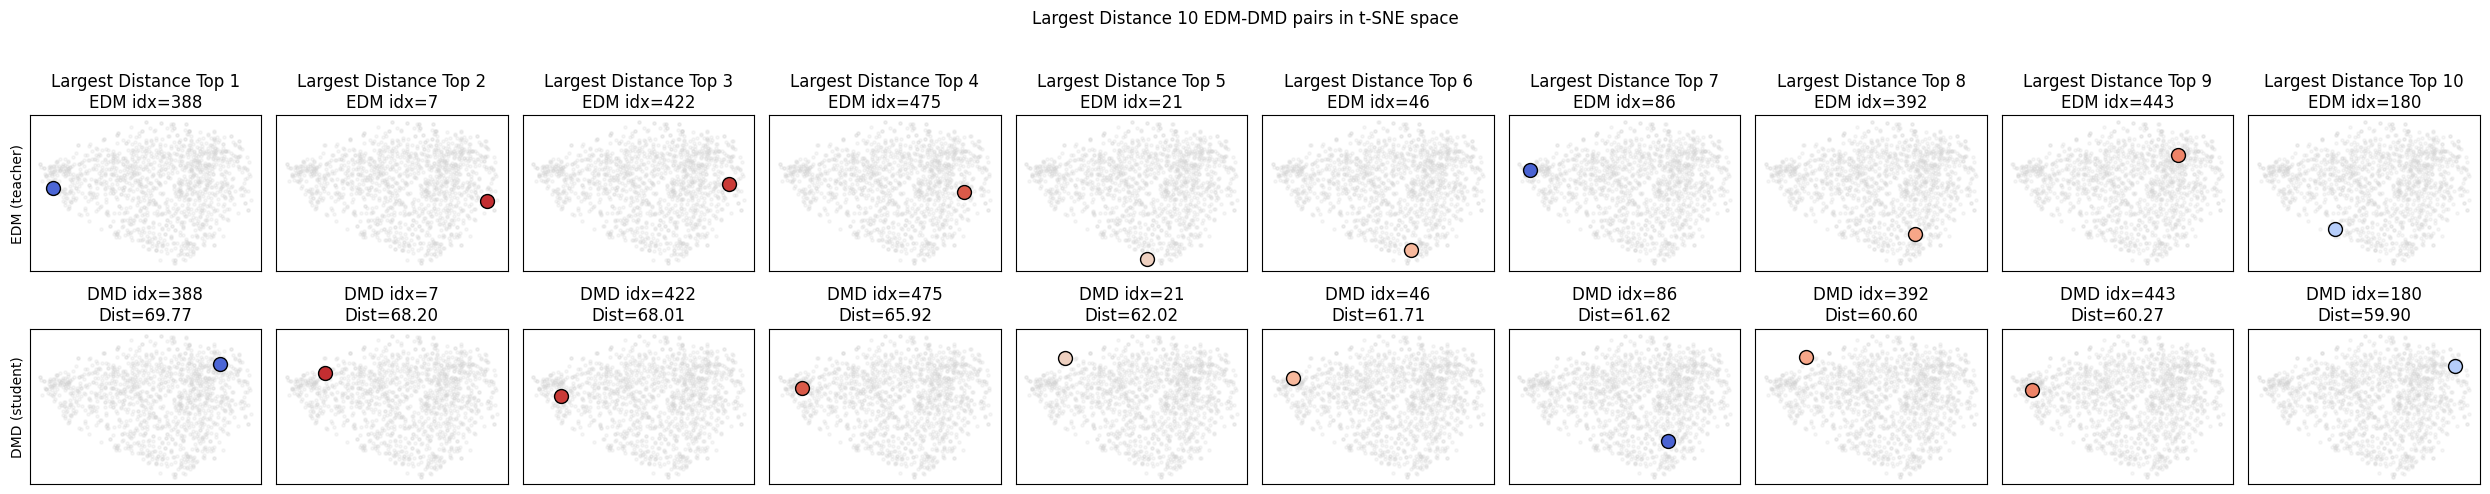

Saved tsne_edm_vs_dmd/248_husky/tSNE_EDM_DMD_largest_10_pairs.png


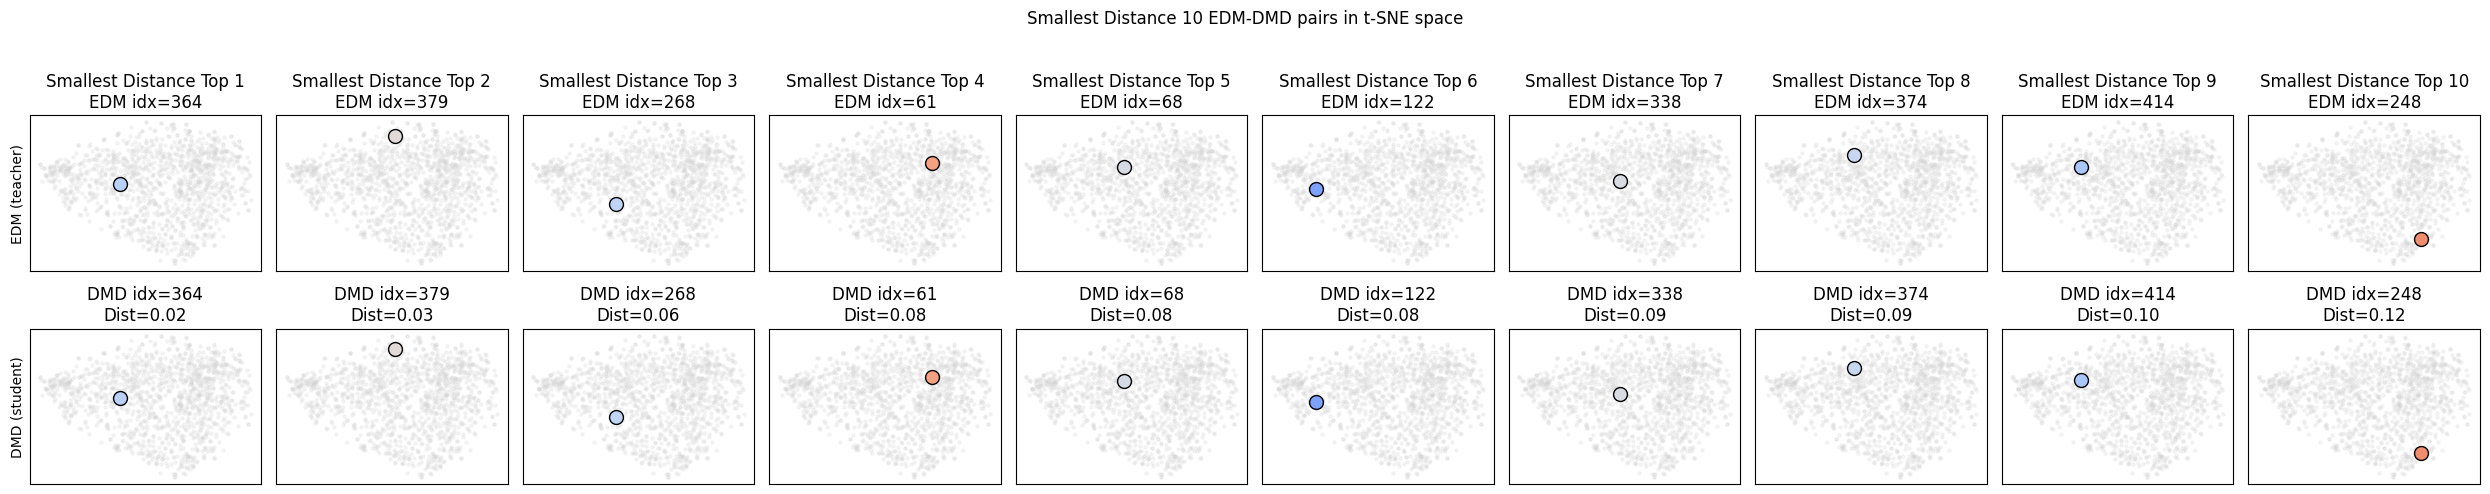

Saved tsne_edm_vs_dmd/248_husky/tSNE_EDM_DMD_smallest_10_pairs.png


In [5]:
# 找出t-SNE空间里EDM和DMD距离最大的K=10和最小的K=10对点，再 pairwise 画对应生成的照片
import os
from PIL import Image

K = 10
# 先算距离并选出最大/最小的 K 对
diffs = edm_N_2d[:min_pairs] - dmd_2d[:min_pairs]
dists = np.linalg.norm(diffs, axis=1)
max_idxs = np.argsort(dists)[-K:][::-1]  # 最大的K个，降序
min_idxs = np.argsort(dists)[:K]         # 最小的K个，升序

# 生成图所在目录（与 tsne_edm_dmd_imagenet.py 保存一致）
edm_N_img_dir = f"{CLASS_DIR}/edm_N_images"
dmd_img_dir = f"{CLASS_DIR}/dmd_images"

def plot_image_pairs(idx_list, title_prefix, edm_dir, dmd_dir, dists_arr):
    """按 index 读取 EDM/DMD 原图并并排画：上排 EDM，下排 DMD。文件名 edm_0000.png / dmd_0000.png"""
    fig, axes = plt.subplots(2, K, figsize=(2.5*K, 5))
    for i, idx in enumerate(idx_list):
        edm_img_path = os.path.join(edm_dir, f"edmN_{idx:04d}.png")
        dmd_img_path = os.path.join(dmd_dir, f"dmd_{idx:04d}.png")
        try:
            edm_img = np.array(Image.open(edm_img_path))
        except Exception as e:
            edm_img = np.zeros((64, 64, 3), dtype=np.uint8)
            print(f"Failed to load {edm_img_path}: {e}")
        try:
            dmd_img = np.array(Image.open(dmd_img_path))
        except Exception as e:
            dmd_img = np.zeros((64, 64, 3), dtype=np.uint8)
            print(f"Failed to load {dmd_img_path}: {e}")
        axes[0, i].imshow(edm_img)
        axes[0, i].axis("off")
        axes[0, i].set_title(f"{title_prefix} #{i+1}\nEDM idx={idx}")
        axes[1, i].imshow(dmd_img)
        axes[1, i].axis("off")
        axes[1, i].set_title(f"DMD idx={idx}\nDist={dists_arr[idx]:.2f}")
    axes[0, 0].set_ylabel("EDM")
    axes[1, 0].set_ylabel("DMD")
    fig.suptitle(f"{title_prefix} — {K} EDM-DMD image pairs")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

fig_max_img = plot_image_pairs(max_idxs, "Largest Distance", edm_N_img_dir, dmd_img_dir, dists)
plt.savefig(f"{CLASS_DIR}/img_EDM_DMD_largest_{K}_pairs.png", dpi=150)
plt.show()
print(f"Saved {CLASS_DIR}/img_EDM_DMD_largest_{K}_pairs.png")

fig_min_img = plot_image_pairs(min_idxs, "Smallest Distance", edm_N_img_dir, dmd_img_dir, dists)
plt.savefig(f"{CLASS_DIR}/img_EDM_DMD_smallest_{K}_pairs.png", dpi=150)
plt.show()
print(f"Saved {CLASS_DIR}/img_EDM_DMD_smallest_{K}_pairs.png")

def plot_pairs(idx_list, title_prefix):
    fig, axes = plt.subplots(2, K, figsize=(2.5*K, 5))
    for i, idx in enumerate(idx_list):
        # EDM
        axes[0, i].scatter(bg_2d[:, 0], bg_2d[:, 1], s=5, c='lightgray', alpha=0.2)
        axes[0, i].scatter(edm_N_2d[idx, 0], edm_N_2d[idx, 1], s=100, color=colors[idx][None, :], edgecolors="black", label="EDM")
        axes[0, i].set_xticks([])
        axes[0, i].set_yticks([])
        axes[0, i].set_title(f"{title_prefix} Top {i+1}\nEDM idx={idx}")
        # DMD
        axes[1, i].scatter(bg_2d[:, 0], bg_2d[:, 1], s=5, c='lightgray', alpha=0.2)
        axes[1, i].scatter(dmd_2d[idx, 0], dmd_2d[idx, 1], s=100, color=colors[idx][None, :], edgecolors="black", label="DMD")
        axes[1, i].set_xticks([])
        axes[1, i].set_yticks([])
        axes[1, i].set_title(f"DMD idx={idx}\nDist={dists[idx]:.2f}")
    axes[0, 0].set_ylabel("EDM (teacher)")
    axes[1, 0].set_ylabel("DMD (student)")
    fig.suptitle(f"{title_prefix} {K} EDM-DMD pairs in t-SNE space")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

fig_max = plot_pairs(max_idxs, "Largest Distance")
plt.savefig(f"{CLASS_DIR}/tSNE_EDM_DMD_largest_{K}_pairs.png", dpi=150)
plt.show()
print(f"Saved {CLASS_DIR}/tSNE_EDM_DMD_largest_{K}_pairs.png")

fig_min = plot_pairs(min_idxs, "Smallest Distance")
plt.savefig(f"{CLASS_DIR}/tSNE_EDM_DMD_smallest_{K}_pairs.png", dpi=150)
plt.show()
print(f"Saved {CLASS_DIR}/tSNE_EDM_DMD_smallest_{K}_pairs.png")

Plot the distribution of distance between DMD and EDM_N images in t-SNE space.

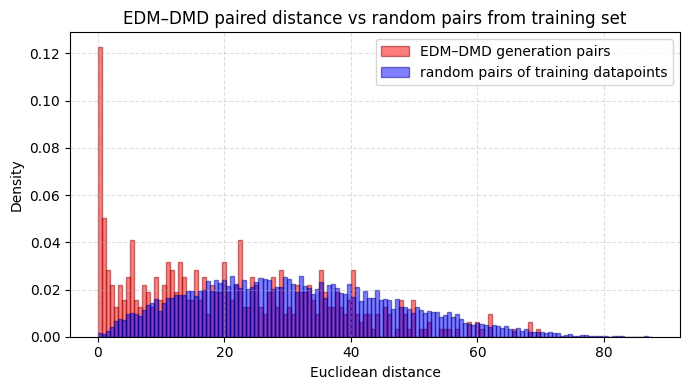

EDM–DMD distance distribution: mean=21.201, std=15.835
Random pairs from training t-SNE: mean=31.253, std=15.860


In [6]:
# Function to simulate distances between two random points in the t-SNE embeddings...
def random_point_in_train_tSNE(bg_2d, n = 10000):
    """Randomly sample n (with replacement) points from training t-SNE embedding."""
    idxs = np.random.choice(bg_2d.shape[0], size=n, replace=True)
    return bg_2d[idxs]

# Sample two sets of random points from training t-SNE embedding and compute distances
n_pairs = 10000
pts1_train = random_point_in_train_tSNE(bg_2d, n_pairs)
pts2_train = random_point_in_train_tSNE(bg_2d, n_pairs)
train_tSNE_rand_dists = np.linalg.norm(pts1_train - pts2_train, axis=1)


# Overlay both distributions (red = EDM-DMD, blue = unit disk)
plt.figure(figsize=(7, 4))
x_max = max(dists.max(), train_tSNE_rand_dists.max())
bins = np.linspace(0, x_max * 1.01, int(dists.max() * 2))
plt.hist(dists, bins=bins, color="red", alpha=0.5, density=True, label="EDM–DMD generation pairs", edgecolor="darkred")
plt.hist(train_tSNE_rand_dists, bins=bins, color="blue", alpha=0.5, density=True, label="random pairs of training datapoints", edgecolor="darkblue")
plt.xlabel("Euclidean distance")
plt.ylabel("Density")
plt.title("EDM–DMD paired distance vs random pairs from training set")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
print(f"EDM–DMD distance distribution: mean={dists.mean():.3f}, std={dists.std():.3f}")
print(f"Random pairs from training t-SNE: mean={train_tSNE_rand_dists.mean():.3f}, std={train_tSNE_rand_dists.std():.3f}")


The distance distribution between EDM and DMD pairs differs from than if random points are picked from the t-SNE of the training datapoints. Statisfically significantly different.

**Notice that EDM_N - DMD distance distribution is NOT attributed to initialization**:

To confirm this, we check if distances of EDM_N - DMD is correlated with EDM_1 - DMD.

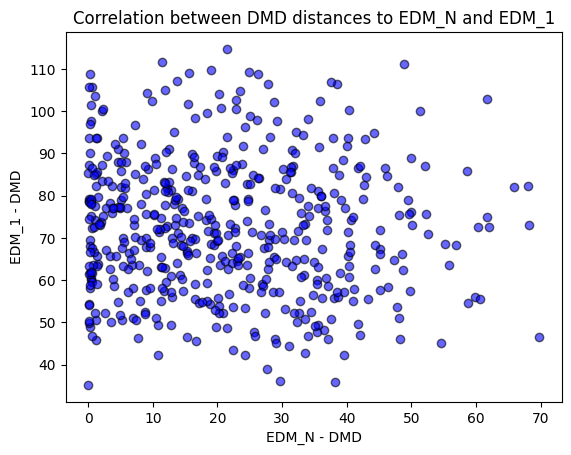

Correlation coefficient: -0.058


In [7]:
edmn_vs_dmd_dists = np.linalg.norm(edm_N_2d - dmd_2d, axis=1)
edm1_vs_dmd_dists = np.linalg.norm(edm_1_2d - dmd_2d, axis=1)

plt.scatter(edmn_vs_dmd_dists, edm1_vs_dmd_dists, alpha=0.6, color = 'blue', edgecolor='k')
plt.xlabel("EDM_N - DMD")
plt.ylabel("EDM_1 - DMD")
plt.title("Correlation between DMD distances to EDM_N and EDM_1")
plt.show()

print(f'Correlation coefficient: {np.corrcoef(edmn_vs_dmd_dists, edm1_vs_dmd_dists)[0, 1]:.3f}')



There is no significant correlation between the initial paired distance and final learned pair distance. 

# 2 Other metrics



## 2.1 EDM_N - DMD: LPIPS

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/slurm-storage/shucli/.conda/envs/dmd2_ot/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/slurm-storage/shucli/.conda/envs/dmd2_ot/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /slurm-storage/shucli/.conda/envs/dmd2_ot/lib/python3.8/site-packages/lpips/weights/v0.1/alex.pth


Random training LPIPS: 100%|██████████| 500/500 [00:01<00:00, 378.90it/s]


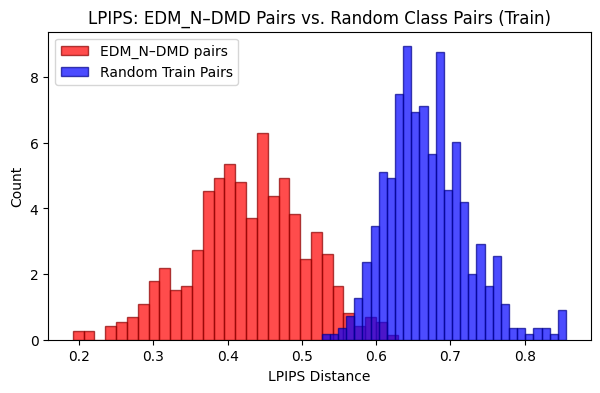

EDM_N–DMD LPIPS: mean=0.428, std=0.077
Random Train LPIPS: mean=0.669, std=0.054


In [8]:
import os
import glob
import torch
import lpips
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

def load_img_lpips(img_path, resize=None):
    img = Image.open(img_path).convert("RGB")
    if resize:
        img = img.resize(resize, Image.BICUBIC)
    img = np.array(img).astype(np.float32)/255.0
    img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    img = img * 2 - 1
    return img
lpips_fn = lpips.LPIPS(net='alex').cuda()

# Resolve project root (cwd may vary)
proj = os.path.abspath(os.getcwd())
for _ in range(6):
    if os.path.exists(os.path.join(proj, "comparison_output", "tsne_edm_vs_dmd")):
        break
    proj = os.path.dirname(proj)
edm_folder = os.path.join(proj, "comparison_output", CLASS_DIR, "edm_N_images")
dmd_folder = os.path.join(proj, "comparison_output", CLASS_DIR, "dmd_images")
edm_imgs = sorted(glob.glob(os.path.join(edm_folder, "*.png")))
dmd_imgs = sorted(glob.glob(os.path.join(dmd_folder, "*.png")))
n_pairs = min(len(edm_imgs), len(dmd_imgs))
img_size = (256, 256)


# Compute LPIPS for corresponding EDM_N-DMD pairs
lpips_scores = []
for i in tqdm(range(n_pairs), desc="EDM_N vs DMD LPIPS"):
    img_edm = load_img_lpips(edm_imgs[i], resize=img_size).cuda()
    img_dmd = load_img_lpips(dmd_imgs[i], resize=img_size).cuda()
    with torch.no_grad():
        score = lpips_fn(img_edm, img_dmd).item()
    lpips_scores.append(score)
lpips_scores = np.array(lpips_scores)

# LPIPS between random training pairs (same class)
import sys
if proj not in sys.path:
    sys.path.insert(0, proj)
from main.data.lmdb_dataset import LMDBDataset
import torch.nn.functional as F

lmdb_path = os.path.join(proj, "model_checkpoints", "imagenet-64x64_lmdb")
train_ds = LMDBDataset(lmdb_path)
train_indices = [i for i in range(len(train_ds)) if train_ds[i]["class_labels"].item() == CLASS_INDEX]

if len(train_indices) < 2:
    print(f"Not enough training images for class {CLASS_INDEX}")
else:
    def to_lpips_tensor(idx):
        img = train_ds[idx]["images"].unsqueeze(0) * 2 - 1
        return F.interpolate(img, size=img_size, mode="bilinear", align_corners=False)

    n_rand = min(1000, len(train_indices) // 2, n_pairs)
    rand_scores = []
    for _ in tqdm(range(n_rand), desc="Random training LPIPS"):
        i1, i2 = random.sample(train_indices, 2)
        img1 = to_lpips_tensor(i1).cuda()
        img2 = to_lpips_tensor(i2).cuda()
        with torch.no_grad():
            score = lpips_fn(img1, img2).item()
        rand_scores.append(score)
    rand_scores = np.array(rand_scores)

    plt.figure(figsize=(7, 4))
    plt.hist(lpips_scores, bins=30, alpha=0.7, label="EDM_N–DMD pairs", density=True, color = 'red', edgecolor = 'darkred')
    plt.hist(rand_scores, bins=30, alpha=0.7, label="Random Train Pairs", density=True, color = 'blue', edgecolor = 'darkblue')
    plt.xlabel("LPIPS Distance")
    plt.ylabel("Count")
    plt.title("LPIPS: EDM_N–DMD Pairs vs. Random Class Pairs (Train)")
    plt.legend()
    plt.show()
    print(f"EDM_N–DMD LPIPS: mean={lpips_scores.mean():.3f}, std={lpips_scores.std():.3f}")
    print(f"Random Train LPIPS: mean={rand_scores.mean():.3f}, std={rand_scores.std():.3f}")


## 2.2 EDM_N - DMD: ResNet + PCA

In [6]:
from sklearn.decomposition import PCA

# Fit PCA on training set only; use as converter for EDM and DMD
pca = PCA(n_components=2).fit(bg_feats)  # PC1 and PC2

# Transform all feature sets using the fitted PCA
bg_pca = pca.transform(bg_feats)
edm_N_pca = pca.transform(edm_N_feats)
edm_1_pca = pca.transform(edm_1_feats)
dmd_pca = pca.transform(dmd_feats)

min_pairs = min(n_edm_N, n_edm_1, n_dmd)
edm_N_pca = edm_N_pca[:min_pairs]
edm_1_pca = edm_1_pca[:min_pairs]
dmd_pca = dmd_pca[:min_pairs]

# Color by EDM_N x-axis (PC1) for consistency with t-SNE style
edm_N_x = edm_N_pca[:, 0]
x_min, x_max = edm_N_x.min(), edm_N_x.max()
x_norm = (edm_N_x - x_min) / (x_max - x_min + 1e-12)
cmap = plt.cm.get_cmap("coolwarm")
colors = cmap(x_norm)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax in axes:
    ax.scatter(bg_pca[:, 0], bg_pca[:, 1], s=5, c="lightgray", alpha=0.2, label="Train")
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].scatter(edm_N_pca[:, 0], edm_N_pca[:, 1], s=10, color=colors, edgecolors="none")
axes[0].set_title("EDM_N")
axes[0].set_xticks([]); axes[0].set_yticks([])

axes[1].scatter(edm_1_pca[:, 0], edm_1_pca[:, 1], s=10, color=colors, edgecolors="none")
axes[1].set_title("EDM_1")
axes[1].set_xticks([]); axes[1].set_yticks([])

axes[2].scatter(dmd_pca[:, 0], dmd_pca[:, 1], s=10, color=colors, edgecolors="none")
axes[2].set_title("DMD")
axes[2].set_xticks([]); axes[2].set_yticks([])

fig.suptitle(f"PCA (PC1, PC2) for EDM_N / EDM_1 / DMD\n{CLASS_DIR}")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{CLASS_DIR}/PCA_EDMN_EDM1_DMD.png", dpi=200)
plt.show()
print(f"Saved {CLASS_DIR}/PCA_EDMN_EDM1_DMD.png")

NameError: name 'bg_feats' is not defined

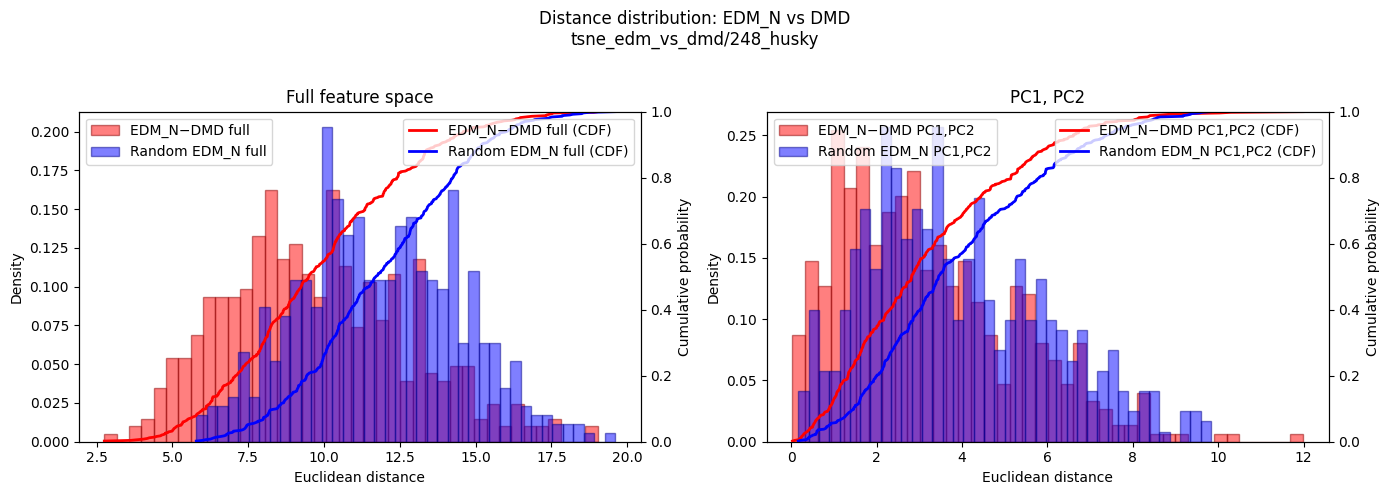

Saved tsne_edm_vs_dmd/248_husky/dist_EDMN_DMD_pca_vs_full.png


In [23]:
# Euclidean distance: EDM_N vs DMD
# (1) In 2 principal components (PC1, PC2)
dists_pca = np.linalg.norm(edm_N_pca - dmd_pca, axis=1)
# (2) In full ResNet feature space
dists_full = np.linalg.norm(edm_N_feats[:min_pairs] - dmd_feats[:min_pairs], axis=1)
# (3) Random pairs from EDM_N set
np.random.seed(0)
n_rand = min_pairs
idx_a = np.random.randint(0, n_edm_N, n_rand)
idx_b = np.random.randint(0, n_edm_N, n_rand)
idx_b = np.where(idx_a != idx_b, idx_b, (idx_b + 1) % n_edm_N)  # ensure i != j
dists_rand_full = np.linalg.norm(edm_N_feats[idx_a] - edm_N_feats[idx_b], axis=1)
dists_rand_pca = np.linalg.norm(edm_N_pca[idx_a] - edm_N_pca[idx_b], axis=1)

bins = 40
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Full feature space
ax0 = axes[0]
ax0.hist(dists_full, bins=bins, alpha=0.5, color="red", label="EDM_N−DMD full", edgecolor = 'darkred', density=True)
ax0.hist(dists_rand_full, bins=bins, alpha=0.5, color="blue", label="Random EDM_N full", edgecolor = 'darkblue', density=True)
ax0.set_xlabel("Euclidean distance")
ax0.set_ylabel("Density")
ax0.set_title("Full feature space")
ax0_twin = ax0.twinx()
x_sort = np.sort(dists_full)
cdf_full = np.arange(1, len(x_sort) + 1) / len(x_sort)
ax0_twin.plot(x_sort, cdf_full, color="red", label="EDM_N−DMD full (CDF)", linewidth=2)
x_sort_r = np.sort(dists_rand_full)
cdf_rand_full = np.arange(1, len(x_sort_r) + 1) / len(x_sort_r)
ax0_twin.plot(x_sort_r, cdf_rand_full, color="blue", label="Random EDM_N full (CDF)", linewidth=2)
ax0_twin.set_ylabel("Cumulative probability")
ax0_twin.set_ylim(0, 1)
ax0.legend(loc="upper left")
ax0_twin.legend(loc="upper right")

# Right: PC1, PC2
ax1 = axes[1]
ax1.hist(dists_pca, bins=bins, alpha=0.5, color="red", edgecolor = 'darkred', label="EDM_N−DMD PC1,PC2", density=True)
ax1.hist(dists_rand_pca, bins=bins, alpha=0.5, color="blue", edgecolor = 'darkblue', label="Random EDM_N PC1,PC2", density=True)
ax1.set_xlabel("Euclidean distance")
ax1.set_ylabel("Density")
ax1.set_title("PC1, PC2")
ax1_twin = ax1.twinx()
x_sort_p = np.sort(dists_pca)
cdf_pca = np.arange(1, len(x_sort_p) + 1) / len(x_sort_p)
ax1_twin.plot(x_sort_p, cdf_pca, color="red", label="EDM_N−DMD PC1,PC2 (CDF)", linewidth=2)
x_sort_rp = np.sort(dists_rand_pca)
cdf_rand_pca = np.arange(1, len(x_sort_rp) + 1) / len(x_sort_rp)
ax1_twin.plot(x_sort_rp, cdf_rand_pca, color="blue", label="Random EDM_N PC1,PC2 (CDF)", linewidth=2)
ax1_twin.set_ylabel("Cumulative probability")
ax1_twin.set_ylim(0, 1)
ax1.legend(loc="upper left")
ax1_twin.legend(loc="upper right")

fig.suptitle(f"Distance distribution: EDM_N vs DMD\n{CLASS_DIR}")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"{CLASS_DIR}/dist_EDMN_DMD_pca_vs_full.png", dpi=200)
plt.show()
print(f"Saved {CLASS_DIR}/dist_EDMN_DMD_pca_vs_full.png")

# 3. Comparison of teacher-student behaviours across different distillation models

## 3.1 MeanFlow Models

## 3.2 Consistency Models

In [10]:
import torch
from diffusers import ConsistencyModelPipeline

device = "cuda"
# Load the cd_imagenet64_l2 checkpoint.
model_id_or_path = "openai/diffusers-cd_imagenet64_l2"
pipe = ConsistencyModelPipeline.from_pretrained(model_id_or_path, torch_dtype=torch.float16)
pipe.to(device)


# Onestep sampling, class-conditional image generation
# ImageNet-64 class label 248 corresponds to husky

class_id = 248
class_id = torch.tensor(class_id, dtype=torch.long)

image = pipe(num_inference_steps=1, class_labels=class_id).images[0]
image.save(f"consistency_model_onestep_sample_{class_id}.png")

# Multistep sampling, class-conditional image generation
# Timesteps can be explicitly specified; the particular timesteps below are from the original Github repo.
# https://github.com/openai/consistency_models/blob/main/scripts/launch.sh#L77
image = pipe(timesteps=[22, 0], class_labels=class_id).images[0]
image.save("consistency_model_multistep_sample_penguin.png")

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Both `num_inference_steps`: 1 and `timesteps`: [22, 0] are supplied; `timesteps` will be used over `num_inference_steps`.


  0%|          | 0/2 [00:00<?, ?it/s]

In [23]:
# ResNet feature extraction for edm_vs_cm generated images
import os
import glob
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm

EDM_CM_DIR = f"edm_vs_cm/{CLASS_DIR.split('/')[-1]}"  # e.g. edm_vs_cm/248_husky

def build_resnet_feature_extractor(device):
    try:
        from torchvision.models import resnet50, ResNet50_Weights
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    except Exception:
        from torchvision.models import resnet50
        backbone = resnet50(pretrained=True)
    feat_ext = torch.nn.Sequential(*list(backbone.children())[:-1])
    feat_ext.to(device).eval()
    for p in feat_ext.parameters():
        p.requires_grad_(False)
    return feat_ext

def load_images_from_dir(img_dir, device, batch_size=64):
    """Load PNGs from dir, return [N, 3, H, W] tensor in [0,1]."""
    paths = sorted(glob.glob(os.path.join(img_dir, "*.png")))
    imgs = []
    for p in paths:
        img = np.array(Image.open(p).convert("RGB"))
        imgs.append(img)
    if not imgs:
        return torch.zeros(0, 3, 64, 64, device=device)
    arr = np.stack(imgs).astype(np.float32) / 255.0  # [N, H, W, 3]
    return torch.from_numpy(arr).permute(0, 3, 1, 2).to(device)

def compute_resnet_features(imgs_chw, feat_ext, device, batch_size=64):
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
    feats = []
    n_batches = (imgs_chw.size(0) + batch_size - 1) // batch_size
    with torch.no_grad():
        for bi in tqdm(range(n_batches), desc="ResNet", unit="batch"):
            batch = imgs_chw[bi * batch_size : (bi + 1) * batch_size]
            batch = F.interpolate(batch, size=(224, 224), mode="bilinear", align_corners=False)
            batch = (batch - mean) / std
            f = feat_ext(batch)
            feats.append(f.view(f.size(0), -1).cpu())
    return torch.cat(feats, dim=0).numpy()

device = "cuda" if torch.cuda.is_available() else "cpu"
feat_ext = build_resnet_feature_extractor(device)

edm1_imgs = load_images_from_dir(f"{EDM_CM_DIR}/edm_1_images", device)
edmN_imgs = load_images_from_dir(f"{EDM_CM_DIR}/edm_N_images", device)
cm_imgs = load_images_from_dir(f"{EDM_CM_DIR}/cm_images", device)

edm1_feats = compute_resnet_features(edm1_imgs, feat_ext, device)
edmN_feats = compute_resnet_features(edmN_imgs, feat_ext, device)
cm_feats = compute_resnet_features(cm_imgs, feat_ext, device)

n_edm1, n_edmN, n_cm = len(edm1_feats), len(edmN_feats), len(cm_feats)
print(f"EDM_1: {n_edm1}, EDM_N: {n_edmN}, CM: {n_cm}")

np.savez_compressed(f"{EDM_CM_DIR}/edm1_feats.npz", features=edm1_feats.astype(np.float32))
np.savez_compressed(f"{EDM_CM_DIR}/edmN_feats.npz", features=edmN_feats.astype(np.float32))
np.savez_compressed(f"{EDM_CM_DIR}/cm_feats.npz", features=cm_feats.astype(np.float32))
print(f"Saved edm1_feats, edmN_feats, cm_feats to {EDM_CM_DIR}")

ResNet: 100%|██████████| 6/6 [00:00<00:00, 18.59batch/s]


EDM_1: 360, EDM_N: 359, CM: 359
Saved edm1_feats, edmN_feats, cm_feats to edm_vs_cm/248_husky


/tmp/ipykernel_3998909/1125531886.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("coolwarm")


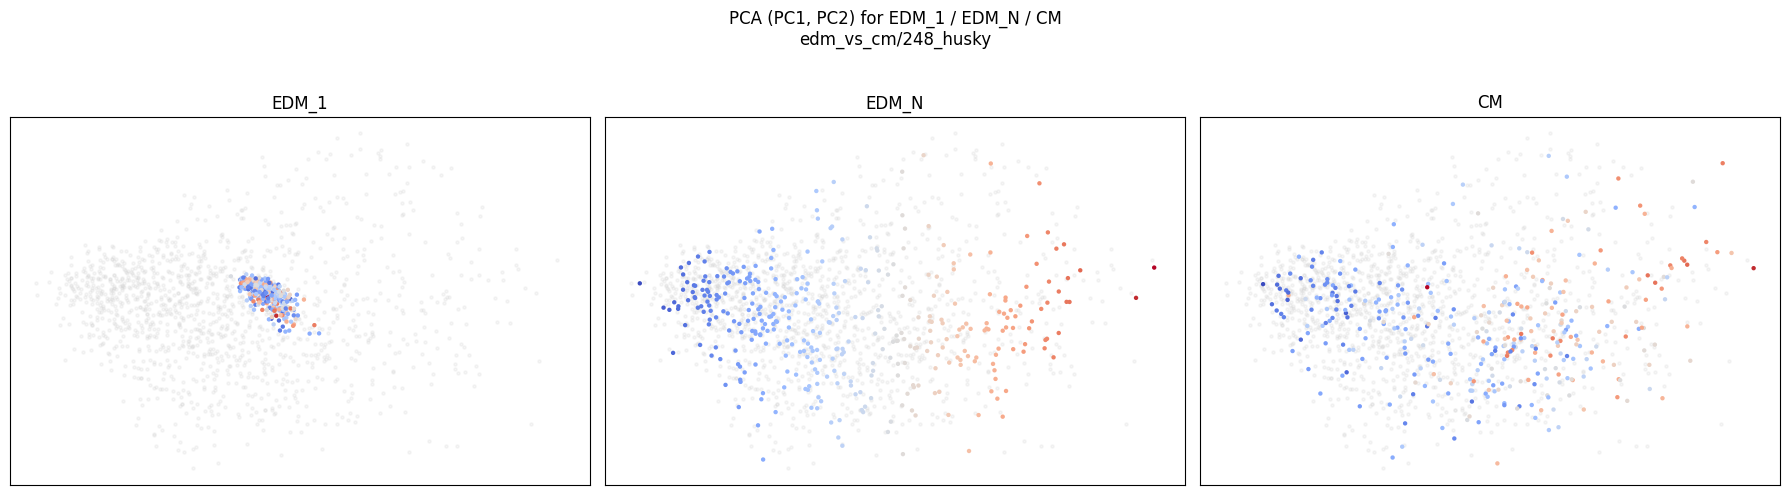

Saved edm_vs_cm/248_husky/PCA_EDM1_EDMN_CM.png


In [24]:
# PCA: fit on training (from tsne_edm_vs_dmd), transform EDM_1, EDM_N, CM (section 2.2 style)
from sklearn.decomposition import PCA

# Load training features for PCA fit (same class from tsne_edm_vs_dmd)
train = np.load(f"{CLASS_DIR}/extrct_training_feats.npz")
bg_feats_cm = train["features"]
n_bg_cm = len(bg_feats_cm)

# Fit PCA on training only; use as converter
pca_cm = PCA(n_components=2).fit(bg_feats_cm)

# Transform all feature sets
bg_pca_cm = pca_cm.transform(bg_feats_cm)
edm1_pca = pca_cm.transform(edm1_feats)
edmN_pca_full = pca_cm.transform(edmN_feats)  # keep full for random-pair distances
cm_pca_full = pca_cm.transform(cm_feats)

min_pairs_cm = min(n_edm1, n_edmN, n_cm)
edm1_pca = edm1_pca[:min_pairs_cm]
edmN_pca = edmN_pca_full[:min_pairs_cm]
cm_pca = cm_pca_full[:min_pairs_cm]

# Color by EDM_N x-axis (PC1) for consistency with t-SNE style
edmN_x = edmN_pca[:, 0]
x_min, x_max = edmN_x.min(), edmN_x.max()
x_norm = (edmN_x - x_min) / (x_max - x_min + 1e-12)
cmap = plt.cm.get_cmap("coolwarm")
colors_cm = cmap(x_norm)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax in axes:
    ax.scatter(bg_pca_cm[:, 0], bg_pca_cm[:, 1], s=5, c="lightgray", alpha=0.2, label="Train")
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].scatter(edm1_pca[:, 0], edm1_pca[:, 1], s=10, color=colors_cm, edgecolors="none")
axes[0].set_title("EDM_1")
axes[0].set_xticks([]); axes[0].set_yticks([])

axes[1].scatter(edmN_pca[:, 0], edmN_pca[:, 1], s=10, color=colors_cm, edgecolors="none")
axes[1].set_title("EDM_N")
axes[1].set_xticks([]); axes[1].set_yticks([])

axes[2].scatter(cm_pca[:, 0], cm_pca[:, 1], s=10, color=colors_cm, edgecolors="none")
axes[2].set_title("CM")
axes[2].set_xticks([]); axes[2].set_yticks([])

fig.suptitle(f"PCA (PC1, PC2) for EDM_1 / EDM_N / CM\n{EDM_CM_DIR}")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{EDM_CM_DIR}/PCA_EDM1_EDMN_CM.png", dpi=200)
plt.show()
print(f"Saved {EDM_CM_DIR}/PCA_EDM1_EDMN_CM.png")

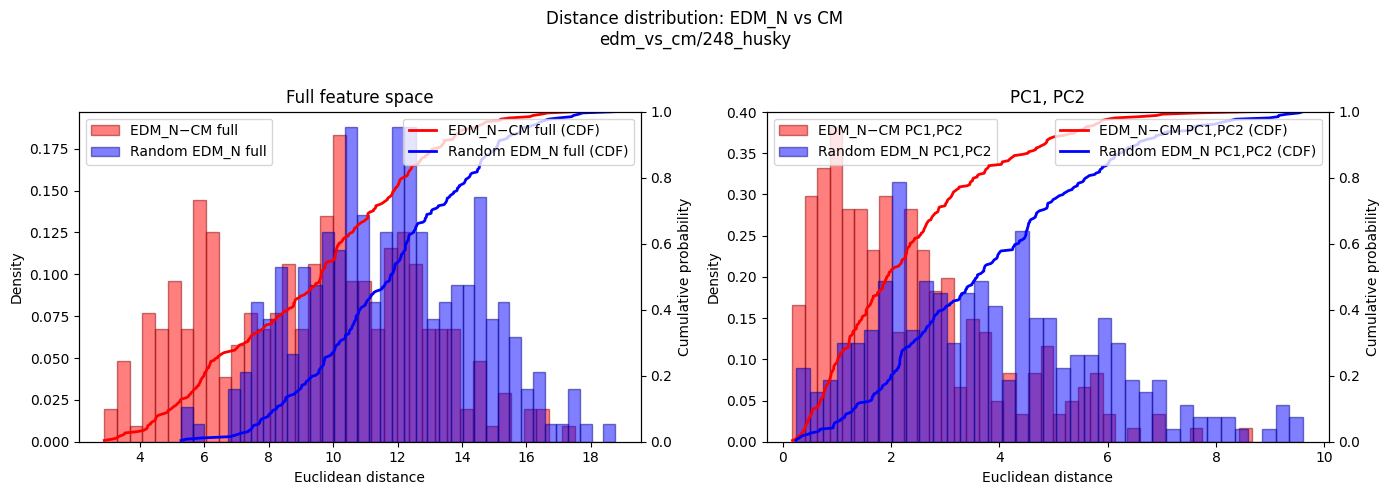

Saved edm_vs_cm/248_husky/dist_EDMN_CM_pca_vs_full.png


In [19]:
# Distance distributions: EDM_N vs CM, and Random EDM_N pairs
# (1) Full feature space
dists_cm_full = np.linalg.norm(edmN_feats[:min_pairs_cm] - cm_feats[:min_pairs_cm], axis=1)
# (2) First 2 PCs
dists_cm_pca = np.linalg.norm(edmN_pca - cm_pca, axis=1)
# (3) Random pairs from EDM_N set
np.random.seed(0)
idx_a = np.random.randint(0, n_edmN, min_pairs_cm)
idx_b = np.random.randint(0, n_edmN, min_pairs_cm)
idx_b = np.where(idx_a != idx_b, idx_b, (idx_b + 1) % n_edmN)
dists_rand_full = np.linalg.norm(edmN_feats[idx_a] - edmN_feats[idx_b], axis=1)
dists_rand_pca = np.linalg.norm(edmN_pca_full[idx_a] - edmN_pca_full[idx_b], axis=1)

bins = int(max(dists_cm_full.max(), dists_rand_full.max()) * 2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Full feature space
ax0 = axes[0]
ax0.hist(dists_cm_full, bins=bins, alpha=0.5, color="red", label="EDM_N−CM full", edgecolor="darkred", density=True)
ax0.hist(dists_rand_full, bins=bins, alpha=0.5, color="blue", label="Random EDM_N full", edgecolor="darkblue", density=True)
ax0.set_xlabel("Euclidean distance")
ax0.set_ylabel("Density")
ax0.set_title("Full feature space")
ax0_twin = ax0.twinx()
x_sort = np.sort(dists_cm_full)
ax0_twin.plot(x_sort, np.arange(1, len(x_sort) + 1) / len(x_sort), color="red", label="EDM_N−CM full (CDF)", linewidth=2)
x_sort_r = np.sort(dists_rand_full)
ax0_twin.plot(x_sort_r, np.arange(1, len(x_sort_r) + 1) / len(x_sort_r), color="blue", label="Random EDM_N full (CDF)", linewidth=2)
ax0_twin.set_ylabel("Cumulative probability")
ax0_twin.set_ylim(0, 1)
ax0.legend(loc="upper left")
ax0_twin.legend(loc="upper right")

# Right: First 2 PCs
ax1 = axes[1]
ax1.hist(dists_cm_pca, bins=bins, alpha=0.5, color="red", edgecolor="darkred", label="EDM_N−CM PC1,PC2", density=True)
ax1.hist(dists_rand_pca, bins=bins, alpha=0.5, color="blue", edgecolor="darkblue", label="Random EDM_N PC1,PC2", density=True)
ax1.set_xlabel("Euclidean distance")
ax1.set_ylabel("Density")
ax1.set_title("PC1, PC2")
ax1_twin = ax1.twinx()
x_sort_p = np.sort(dists_cm_pca)
ax1_twin.plot(x_sort_p, np.arange(1, len(x_sort_p) + 1) / len(x_sort_p), color="red", label="EDM_N−CM PC1,PC2 (CDF)", linewidth=2)
x_sort_rp = np.sort(dists_rand_pca)
ax1_twin.plot(x_sort_rp, np.arange(1, len(x_sort_rp) + 1) / len(x_sort_rp), color="blue", label="Random EDM_N PC1,PC2 (CDF)", linewidth=2)
ax1_twin.set_ylabel("Cumulative probability")
ax1_twin.set_ylim(0, 1)
ax1.legend(loc="upper left")
ax1_twin.legend(loc="upper right")

fig.suptitle(f"Distance distribution: EDM_N vs CM\n{EDM_CM_DIR}")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"{EDM_CM_DIR}/dist_EDMN_CM_pca_vs_full.png", dpi=200)
plt.show()
print(f"Saved {EDM_CM_DIR}/dist_EDMN_CM_pca_vs_full.png")

----

## EDM denoise–renoise–denoise (Golden Retriever)
Denoise noise → time 0 (1 step), renoise to time 0.99, denoise again (1 step). Store 3 images.

In [2]:
# EDM denoise–renoise–denoise for Golden Retriever (class 207)
import os
import sys
import pickle
import numpy as np
import torch
from PIL import Image

# Add DMD2_OT to path for imports
_cwd = os.getcwd()
if "comparison_output" in _cwd:
    PROJECT_ROOT = os.path.dirname(_cwd)
else:
    PROJECT_ROOT = _cwd
sys.path.insert(0, PROJECT_ROOT)

import dnnlib

RESOLUTION = 64
LABEL_DIM = 1000
SIGMA_MAX = 80.0
CLASS_GOLDEN_RETRIEVER = 207

# Checkpoint: "edm_imagenet-64x64" -> model_checkpoints/edm-imagenet-64x64-cond-adm.pkl
EDM_CKPT = os.path.join(PROJECT_ROOT, "model_checkpoints", "edm-imagenet-64x64-cond-adm.pkl")
OUT_DIR = os.path.join(PROJECT_ROOT, "comparison_output", "renoises")
os.makedirs(OUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load EDM
with dnnlib.util.open_url(EDM_CKPT) as f:
    edm_net = pickle.load(f)["ema"].to(device)
edm_net.eval()

# Fixed seed for reproducibility
torch.manual_seed(42)
noise = torch.randn(1, 3, RESOLUTION, RESOLUTION, device=device)
one_hot = torch.zeros(1, LABEL_DIM, device=device)
one_hot[0, CLASS_GOLDEN_RETRIEVER] = 1.0

def to_uint8(x):
    """x: [B,3,H,W] in [-1,1] -> uint8 [B,H,W,3]"""
    out = ((x + 1.0) * 127.5).clamp(0, 255).to(torch.uint8)
    return out.permute(0, 2, 3, 1).cpu().numpy()

with torch.no_grad():
    # 1) Denoise noise → time 0 (1 step)
    x_noisy = noise * SIGMA_MAX
    sigma = torch.ones(1, device=device) * SIGMA_MAX
    x_clean = edm_net(x_noisy, sigma, one_hot)
    img0 = to_uint8(x_clean)[0]
    Image.fromarray(img0, mode="RGB").save(os.path.join(OUT_DIR, "1_denoise_to_t0.png"))

    # 2) Renoise to time 0.99 (sigma = 0.99 * sigma_max)
    t_renoise = 0.9
    sigma_renoise = t_renoise * SIGMA_MAX
    z_renoise = torch.randn_like(x_clean, device=device)
    x_renoised = x_clean + sigma_renoise * z_renoise
    # Normalize noisy image for visualization (values can be large)
    xn = x_renoised[0].cpu().numpy()
    xn = (xn - xn.min()) / (xn.max() - xn.min() + 1e-8) * 255
    Image.fromarray(xn.astype(np.uint8).transpose(1, 2, 0), mode="RGB").save(
        os.path.join(OUT_DIR, "2_renoise_to_t099.png")
    )

    # 3) Denoise again (1 step)
    sigma_2 = torch.ones(1, device=device) * sigma_renoise
    x_clean2 = edm_net(x_renoised, sigma_2, one_hot)
    img2 = to_uint8(x_clean2)[0]
    Image.fromarray(img2, mode="RGB").save(os.path.join(OUT_DIR, "3_denoise_again.png"))

print(f"Saved 3 images to {OUT_DIR}")
print("  1_denoise_to_t0.png   - first denoise (noise → clean)")
print("  2_renoise_to_t099.png - renoised to time 0.99")
print("  3_denoise_again.png   - second denoise")

Saved 3 images to /mnt/data/slurm-storage/shucli/PROJECT_FOLDER/DMD2_OT/comparison_output/renoises
  1_denoise_to_t0.png   - first denoise (noise → clean)
  2_renoise_to_t099.png - renoised to time 0.99
  3_denoise_again.png   - second denoise
